In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import os
import logging

import matplotlib.pyplot as plt  # type: ignore
import numpy as np

import lenspyx
import healpy as hp
from tqdm.auto import tqdm

from pixell import curvedsky, enmap, reproject

from ksw import KSW, Shape

from scripts import Core
from scripts.utils import (
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_predictions,
    plot_histogram,
    plot_mollview,
    plot_elsner_comp,
    pol_str,
)
from scripts.generator import generate_alm, generate_alm_ng
from scripts.utils.utils import print_errors, trim_alms

logger = setup_logging(__name__, level=logging.DEBUG)

## Elsner test

This downloads the elsner sims and prints them out as a test comparison for the linear and non-linear alms.

To download uncomment the first cell, the second cell will just plot the sims. You only need the first sim if it is taking a long time.

In [3]:
# import requests

# for num in range(1, 1001):
#     URL1 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_l_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )
#     URL2 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_nl_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )

#     file1 = "data/elsner/alm_l_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file1):
#         with requests.Session() as s, open(file1, "wb") as f:
#             f.write(s.get(URL1).content)

#     file2 = "data/elsner/alm_nl_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file2):
#         with requests.Session() as s, open(file2, "wb") as f:
#             f.write(s.get(URL2).content)

#     print(f"Finished {num}")

In [4]:
core = Core(
    [
        "settings/elsner.json",
        "--nsims",
        "30",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        "--pols",
        "TE",
        # "--lmax",
        # "300",
    ]
)

01-Oct-24 15:36:03 - scripts.core - INFO - Parsing CLI args: ['settings/elsner.json', '--nsims', '30', '--narray', '1', '--fnl_range', '-100', '100', '--pols', 'TE']
01-Oct-24 15:36:03 - scripts.core - INFO - Loading settings from file settings/elsner.json
01-Oct-24 15:36:03 - scripts.core - DEBUG - Forcing setting 'nsims' to '30' due to CLI
01-Oct-24 15:36:03 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
01-Oct-24 15:36:03 - scripts.core - DEBUG - Forcing setting 'fnl_range' to '[-100.0, 100.0]' due to CLI
01-Oct-24 15:36:03 - scripts.core - DEBUG - Forcing setting 'pols' to '['TE']' due to CLI
01-Oct-24 15:36:03 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0.02256, 'omch2': 0.1143, 'tau': 0.084} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05})
01-Oct-24 15:36:03 - scripts.core - DEBUG - Overriding cosmo param As from 2.13e-09 to 2.457e-09
01-Oct-24 15

In [5]:
from ksw import Cosmology
import camb

cosmo = Cosmology(camb.set_params(**core.cosmo_params))
# cosmo.compute_transfer(core.max_l)
cosmo.compute_transfer(core.lmax)
cosmo.compute_c_ell()

if core.lensing:
    c_ells = cosmo.c_ell["lensed_scalar"]["c_ell"].T
else:
    c_ells = cosmo.c_ell["unlensed_scalar"]["c_ell"].T

In [6]:
alm_l = generate_alm(core, c_ells)
alm_ng = generate_alm_ng(core, cosmo, alm_l, c_ells)

01-Oct-24 15:36:23 - generator - DEBUG - Using temp folder for Alm_ng generation: /lustre/scratch/client/users/stevensonb
01-Oct-24 15:36:23 - generator - DEBUG - Starting...


Alm_ng:   0%|          | 0/30 [00:00<?, ?it/s]

/lustre/work/client/users/stevensonb/.conda/envs/mlpng/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [7]:
idx = str(1).zfill(4)
base1 = f"data/elsner/alm_l_{idx}_v3.fits"
base2 = f"data/elsner/alm_nl_{idx}_v3.fits"

# these load the TT, EE, TE alms
alm_elsner_l = np.array(hp.read_alm(base1, hdu=(1, 2, 3)))
alm_elsner_nl = np.array(hp.read_alm(base2, hdu=(1, 2, 3)))

t_scale = cosmo.camb_params.TCMB * 1e6
alm_elsner_l *= t_scale
alm_elsner_nl *= t_scale

In [8]:
# plot_elsner_comp(alm_l[0], alm_ng[0], elsner_idx=core.rng.integers(1, 1001), show=True)

# alm_l_avg = np.mean(alm_l, axis=0)
# alm_ng_avg = np.mean(alm_ng, axis=0)
# plot_elsner_comp(
#     alm_l_avg,
#     alm_ng_avg,
#     elsner_idx=core.rng.integers(1, 1001),
#     title="avged comp",
#     show=True,
#     plot_func=plt.loglog,
# )

In [9]:
icov = 1 / c_ells
icov = icov[core.pol_idxs()]


def icov_func(alm):
    ret = np.zeros_like(alm)
    for pol in range(np.shape(alm)[0]):
        # we drop TE
        ret[pol] = hp.almxfl(alm[pol], icov[pol])
    return ret

/tmp/ipykernel_1314892/65749807.py:1: RuntimeWarning: divide by zero encountered in divide
  icov = 1 / c_ells


In [10]:
loc_shape = Shape.prim_local(core.cosmo_params["ns"], core.cosmo_params["pivot_scalar"])
cosmo.add_prim_reduced_bispectrum(loc_shape, core.radii)

ksw = KSW(
    cosmo.red_bispectra,
    lambda a: a,
    core.lmax,
    core.pols,
    core.precision,
)

theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus

if core.force_ksw:
    if os.path.exists(core.mc_file):
        logger.info("Loading KSW state from %s", core.mc_file)
        ksw.start_from_read_state(core.mc_file)
    else:
        alm_steps = generate_alm(core, 100)
        logger.debug("Done")

        def step_loader(idx):
            """for stepping the KSW estimator, we just generate new unique sims"""
            logger.debug("Sending alm step %s", idx)
            return alm_steps[idx, : core.npols]

        logger.info("Running KSW step, num steps: %s", 100)
        ksw.step_batch(step_loader, range(100), theta_batch=theta_batch)

        # save the mc state if we are using the mc file
        if True:
            logger.info("Saving KSW state to %s", core.mc_file)
            ksw.write_state(core.mc_file)
else:
    with np.errstate(divide="ignore", invalid="ignore"):
        ib = np.where(core.beam_ell != 0, 1 / core.beam_ell, 0)
        cl = c_ells
        icov = np.where(
            cl + ib * core.noise_ell * ib != 0,
            1 / (cl + ib * core.noise_ell * ib),
            0,
        )
        icov = icov[core.pol_idxs()]

    fisher = ksw.compute_fisher_isotropic(icov)
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

Fisher: 0.08499200642108917, standard deviation: 3.430132973443544


In [11]:
pbar = tqdm(total=core.nsims, desc="Computing estimates")

idxs = range(1, core.nsims + 1)
fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims,))


def icov_func(alm):
    ret = np.zeros_like(alm)
    for pol in range(core.npols):
        ret[pol] = hp.almxfl(alm[pol], icov[pol])
    return ret


def alm_loader(i):
    idx = str(i).zfill(4)
    base1 = f"data/elsner/alm_l_{idx}_v3.fits"
    base2 = f"data/elsner/alm_nl_{idx}_v3.fits"

    # these load the TT, EE, TE alms
    l = np.array(hp.read_alm(base1, hdu=(1, 2)))[: core.npols]
    nl = np.array(hp.read_alm(base2, hdu=(1, 2)))[: core.npols]

    alms = icov_func((l + fnls[i - 1] * nl) * t_scale)

    # need sto trim the values if we are using a lower lmax, throw error if asking for higher lmax
    lmax = hp.Alm.getlmax(alms.shape[-1])
    if lmax < core.lmax:
        # this could be done earlyer but this is just test code so not super important to optimize
        raise ValueError(
            "alm has lmax %s < %s which cannot be resolved", lmax, core.lmax
        )
    if lmax > core.lmax:
        # logger.debug("Trimming alm from lmax %s to %s", lmax, core.lmax)
        alms = trim_alms(alms, core.lmax)
    pbar.update(1)
    return alms


# icov_alms = [icov_func(alm_loader(i)) for i in idxs]
estimates, _, _, _ = ksw.compute_estimate_batch(
    lambda i: alm_loader(i), idxs, theta_batch=theta_batch, fisher=fisher, lin_term=0
)
pbar.close()

Computing estimates:   0%|          | 0/30 [00:00<?, ?it/s]

fnl=54.924833238817115, t_cubic=4.668171779310796, lin_term=0, fisher=0.08499201
fnl=12.65331135880613, t_cubic=1.0754303202556912, lin_term=0, fisher=0.08499201
fnl=44.64284797335886, t_cubic=3.7942852216074243, lin_term=0, fisher=0.08499201
fnl=-74.53442005377364, t_cubic=-6.334829907802487, lin_term=0, fisher=0.08499201
fnl=23.33981461689396, t_cubic=1.9836976737860823, lin_term=0, fisher=0.08499201
fnl=103.58005578023041, t_cubic=8.803476765970117, lin_term=0, fisher=0.08499201
fnl=-11.47095264122282, t_cubic=-0.9749392805388197, lin_term=0, fisher=0.08499201
fnl=-82.09572231307672, t_cubic=-6.97748015797697, lin_term=0, fisher=0.08499201
fnl=85.26755733229533, t_cubic=7.2470607802970335, lin_term=0, fisher=0.08499201
fnl=29.349728929541964, t_cubic=2.4944923496368574, lin_term=0, fisher=0.08499201
fnl=-59.383644845792006, t_cubic=-5.047135124041233, lin_term=0, fisher=0.08499201
fnl=33.04464820815908, t_cubic=2.8085309526904894, lin_term=0, fisher=0.08499201
fnl=95.2884235337922, 

[ 56.22351776  21.16940591  41.96023808 -82.18042542  26.14288317
  96.16214044 -15.31896553 -77.51938333  91.65328907  35.19643698
 -60.56145281  34.41185131  98.54832555 -58.1029052   70.7719597
  39.78215705 -55.66499448 -63.04565355  90.83140644 -31.91249448
 -11.7211002   31.21747035 -11.93961926 -99.9470992  -47.94882592
  -5.55290106  52.25368881  21.27726813 -13.96099415 -61.79430731]
01-Oct-24 16:25:58 - scripts.utils.utils - INFO - Standard deviation: 3.4301329951056907, SEM: 0.6262537388873815
01-Oct-24 16:25:58 - scripts.utils.utils - INFO - 36.666666666666664% (30.0, 43.333333333333336) are within 1 standard deviations
01-Oct-24 16:25:58 - scripts.utils.utils - INFO - 73.33333333333333% (63.33333333333333, 83.33333333333334) are within 2 standard deviations
01-Oct-24 16:25:58 - scripts.utils.utils - INFO - 96.66666666666667% (83.33333333333334, 96.66666666666667) are within 3 standard deviations
01-Oct-24 16:25:58 - scripts.utils.utils - INFO - 96.66666666666667% (96.66666

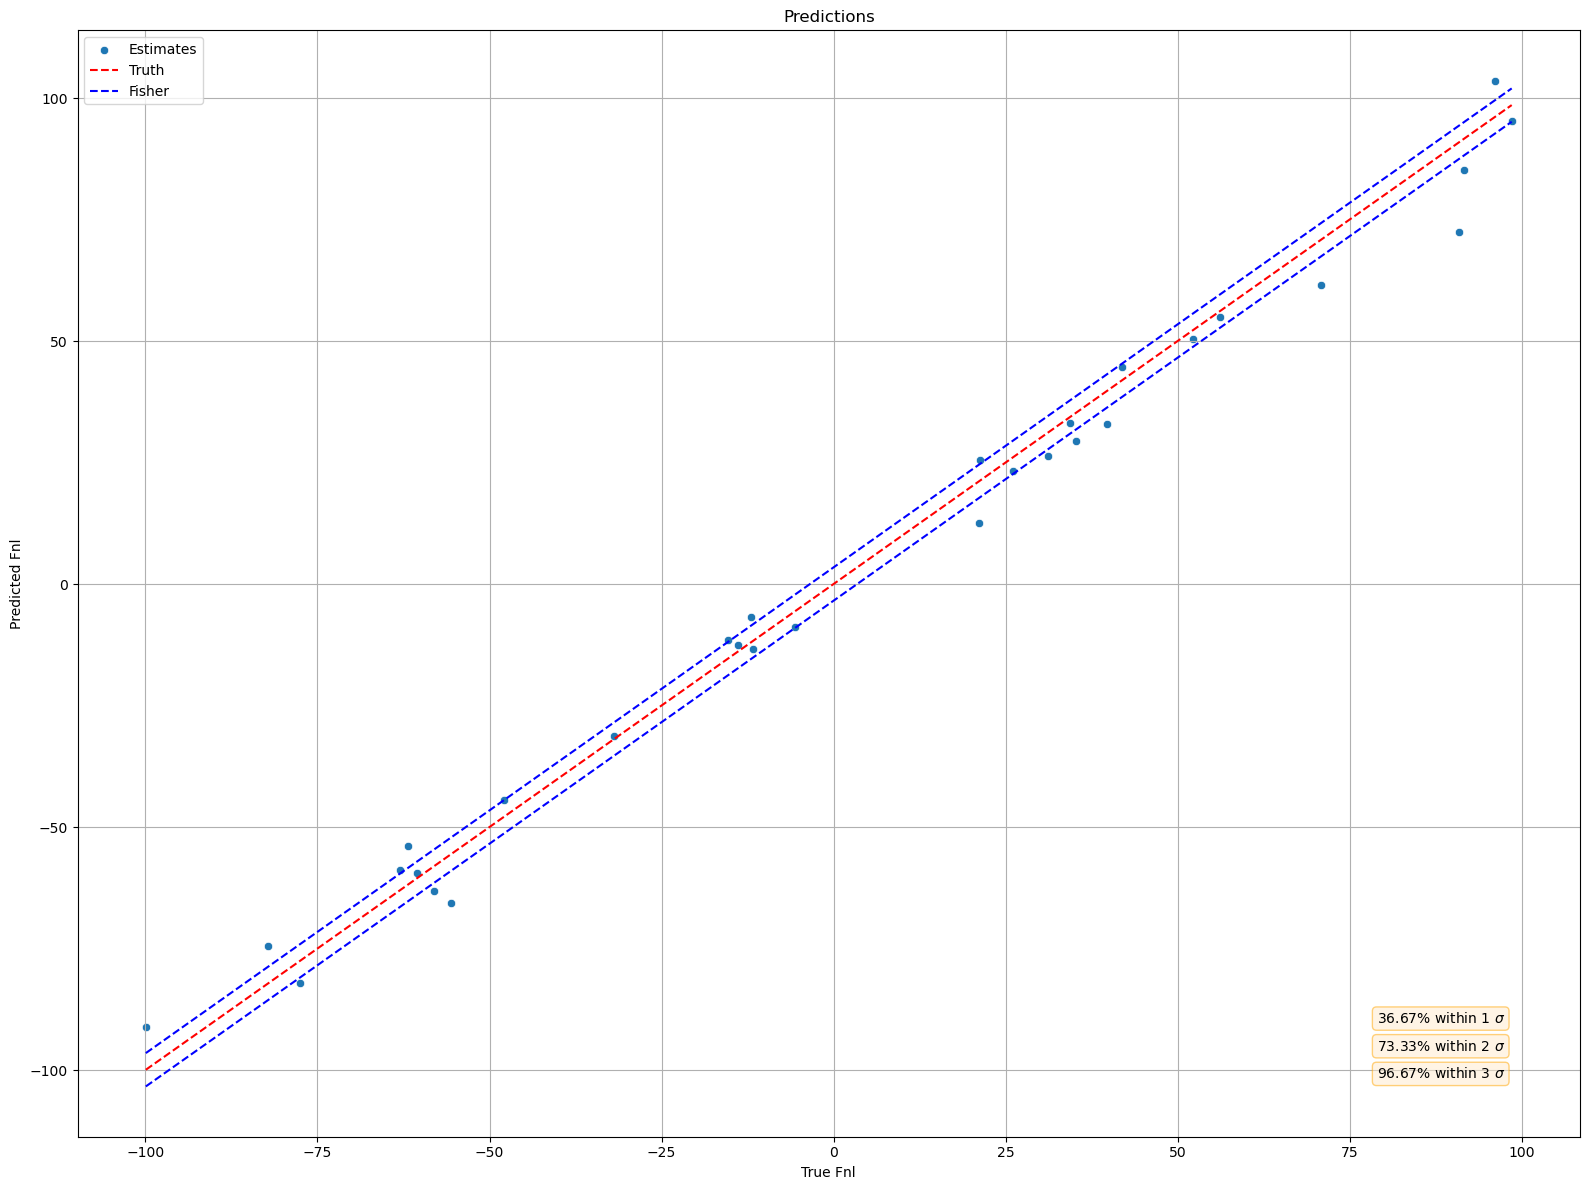

In [12]:
print(fnls)
print_errors(fnls, estimates, fisher)
plot_predictions(fnls, estimates, fisher=fisher, show=True)
plot_histogram(fnls, estimates)

## Setup

In [13]:
core = Core(
    [
        # "settings/n128.json",
        "settings/elsner.json",
        # "settings/planck.json",
        "--nsims",
        "30",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        # "--lmax",
        # "383",
        # "--nside",
        # "128",
        "--pols",
        "TE",
        "--no-noise",
        "--no-lensing",
    ]
)

01-Oct-24 16:26:01 - scripts.core - INFO - Parsing CLI args: ['settings/elsner.json', '--nsims', '30', '--narray', '1', '--fnl_range', '-100', '100', '--pols', 'TE', '--no-noise', '--no-lensing']
01-Oct-24 16:26:01 - scripts.core - INFO - Loading settings from file settings/elsner.json
01-Oct-24 16:26:01 - scripts.core - DEBUG - Forcing setting 'nsims' to '30' due to CLI
01-Oct-24 16:26:01 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
01-Oct-24 16:26:01 - scripts.core - DEBUG - Forcing setting 'fnl_range' to '[-100.0, 100.0]' due to CLI
01-Oct-24 16:26:01 - scripts.core - DEBUG - Forcing setting 'pols' to '['TE']' due to CLI
01-Oct-24 16:26:01 - scripts.core - DEBUG - Forcing setting 'lensing' to 'False' due to CLI
01-Oct-24 16:26:01 - scripts.core - DEBUG - Forcing setting 'noise' to 'False' due to CLI
01-Oct-24 16:26:01 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [14]:
from ksw import Cosmology
import camb

cosmo = Cosmology(camb.set_params(**core.cosmo_params))
# cosmo.compute_transfer(core.max_l)
cosmo.compute_transfer(core.lmax)
cosmo.compute_c_ell()

if core.lensing:
    c_ells = cosmo.c_ell["lensed_scalar"]["c_ell"].T
else:
    c_ells = cosmo.c_ell["unlensed_scalar"]["c_ell"].T
c_ells = c_ells[:, : core.nell]  # trim c_ells to the correct length

alm_l = generate_alm(core, c_ells)
alm_ng = generate_alm_ng(core, cosmo, alm_l, c_ells)

fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims,))

# print(alm_l.shape, alm_ng.shape)
alms = alm_l + fnls[:, None, None] * alm_ng

01-Oct-24 16:26:19 - generator - DEBUG - Using temp folder for Alm_ng generation: /lustre/scratch/client/users/stevensonb
01-Oct-24 16:26:19 - generator - DEBUG - Starting...


Alm_ng:   0%|          | 0/30 [00:00<?, ?it/s]

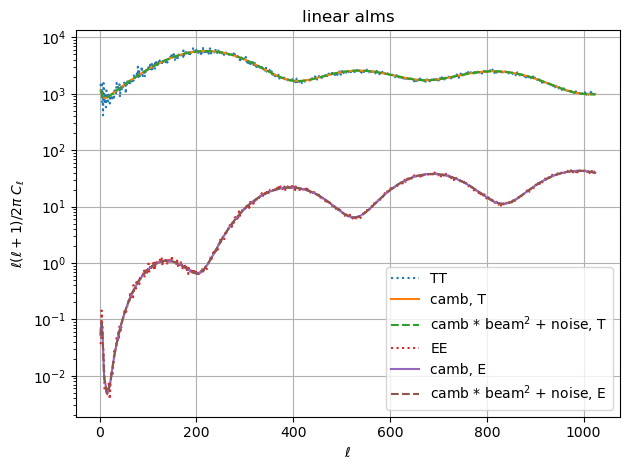

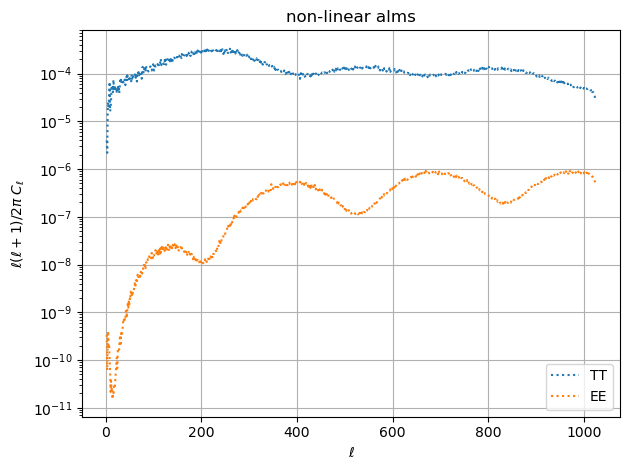

In [15]:
plt_labels = ["TT", "EE"][: core.npols]

plot_cl_alm(
    alm_l[0, :2],
    title="linear alms",
    labels=plt_labels,
    plot_camb=True,
    camb_cls=c_ells,
    plot_noise=False,
    camb_noise=core.noise_ell,
    plot_full_camb=True,
    camb_beam=core.beam_ell,
    show=True,
)

plot_cl_alm(alm_ng[0], labels=plt_labels, title="non-linear alms", show=True)

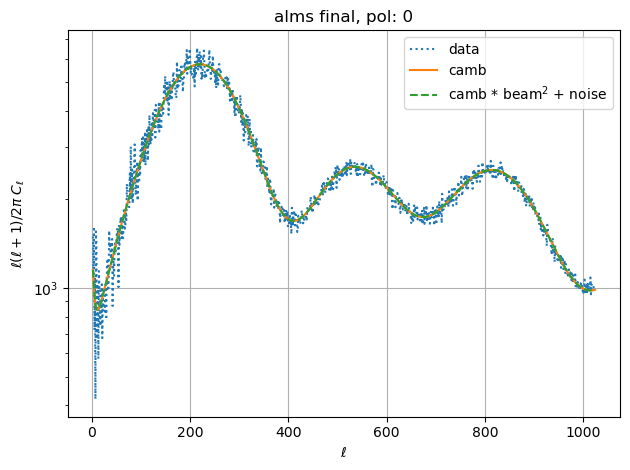

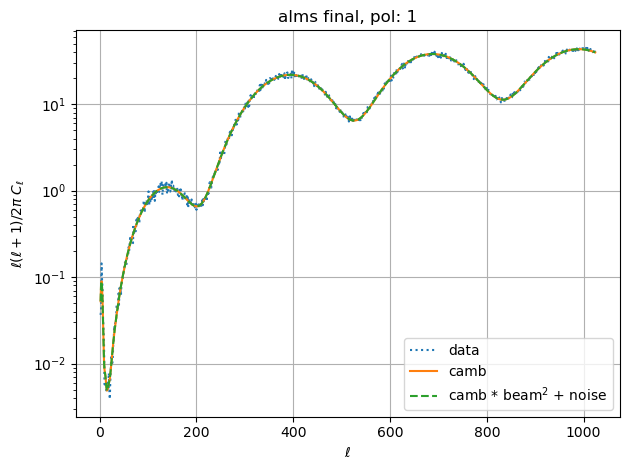

In [16]:
for pol in range(core.npols):
    plot_cl_alm(
        alms[0, pol],
        title=f"alms final, pol: {pol}",
        plot_camb=True,
        camb_cls=c_ells[pol],
        plot_noise=False,
        camb_noise=core.noise_ell[pol],
        plot_full_camb=True,
        camb_beam=core.beam_ell[pol],
        show=True,
    )

## Lensing and Patching

In [17]:
ps_rad = np.deg2rad(core.patch_side_deg)
res = ps_rad / core.nside

fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
# need to add a B mode dim if we are using E modes, this is used for some lensing
full_pol = core.npols + (1 if core.use_e else 0)
fs_shape = (full_pol,) + fs_shape
fs_map = enmap.zeros(fs_shape, fs_wcs)

patch_shapes = []
patch_wcss = []
for counter in range(core.npatches // 2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=top, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

In [18]:
# convert the map into a pixell map to allow for projection
if core.lensing:
    # cl_phi is PP, PT, PE
    cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        core.lmax, CMB_unit="muK", raw_cl=True
    )
    plm = lenspyx.utils_hp.synalm(cl_phi[:, 0], lmax=core.lmax, mmax=None)

    # transform the lensing potential into spin-1 deflection field
    fl = np.sqrt(np.arange(core.nell) * np.arange(1, core.nell + 1))
    dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=False)

    geom_info = ("healpix", {"nside": core.nside})
    geom = lenspyx.get_geom(geom_info)

    patches = np.zeros(
        (core.nsims, core.npatches, full_pol, core.nside, core.nside),
        dtype=core.r_dtype,
    )

    alm_lensed = np.zeros((core.nsims, full_pol, core.nelem), dtype=core.c_dtype)
    for sim in tqdm(range(core.nsims), desc="Lensing and Patching", total=core.nsims):
        T, Q, U = lenspyx.alm2lenmap(
            alms[sim], dlm, geometry=geom_info, nthreads=core.n_cpus
        )

        if core.use_t:
            alm_lensed[sim, 0] = geom.map2alm(
                T.copy(), core.lmax, core.lmax, nthreads=core.n_cpus
            )

        if core.use_e:
            idx = 1 if core.use_t else 0
            alm_lensed[sim, idx : idx + 2] = geom.map2alm_spin(
                [Q.copy(), U.copy()], 2, core.lmax, core.lmax, nthreads=core.n_cpus
            )

        pixell_map = reproject.healpix2map([T, Q, U], fs_shape, fs_wcs, core.lmax)

        # cut the patches
        for i in range(core.npatches):
            patches[sim, i] = pixell_map.project(patch_shapes[i], patch_wcss[i])

    # lets make a plot
    sim = core.rng.integers(core.nsims)
    # Create a figure with subplots
    fig, axes = plt.subplots(
        1, core.npols, figsize=(15, 5), subplot_kw={"projection": "mollweide"}
    )
    axes = np.atleast_1d(axes)
    for pol in range(core.npols):
        # Create the mollview plot in the corresponding subplot
        plt.axes(axes[pol])
        hp.mollview(
            [T, Q, U][pol], title=f"Simulation {sim}, Polarization {pol}", hold=True
        )

else:
    patches = np.zeros(
        (core.nsims, core.npatches, core.npols, core.nside, core.nside),
        dtype=core.r_dtype,
    )

    maps = alms.copy()
    if core.use_e:
        # need to add a zero for the spin-2 component
        maps = np.concatenate((maps, np.zeros((core.nsims, 1, core.nelem))), axis=1)

    # we need to build the spin matrix paramters, T = 0, E = 2
    spin = []
    if core.use_t:
        spin.append(0)
    if core.use_e:
        spin.append(2)

    for sim in tqdm(range(core.nsims), desc="Patching", total=core.nsims):
        car_map = curvedsky.alm2map(
            maps[sim], fs_map, spin=spin, nthread=core.n_cpus, copy=True
        )

        for i in range(core.npatches):
            patches[sim, i] = car_map.project(patch_shapes[i], patch_wcss[i])[
                : core.npols
            ]  # type: ignore

Patching:   0%|          | 0/30 [00:00<?, ?it/s]

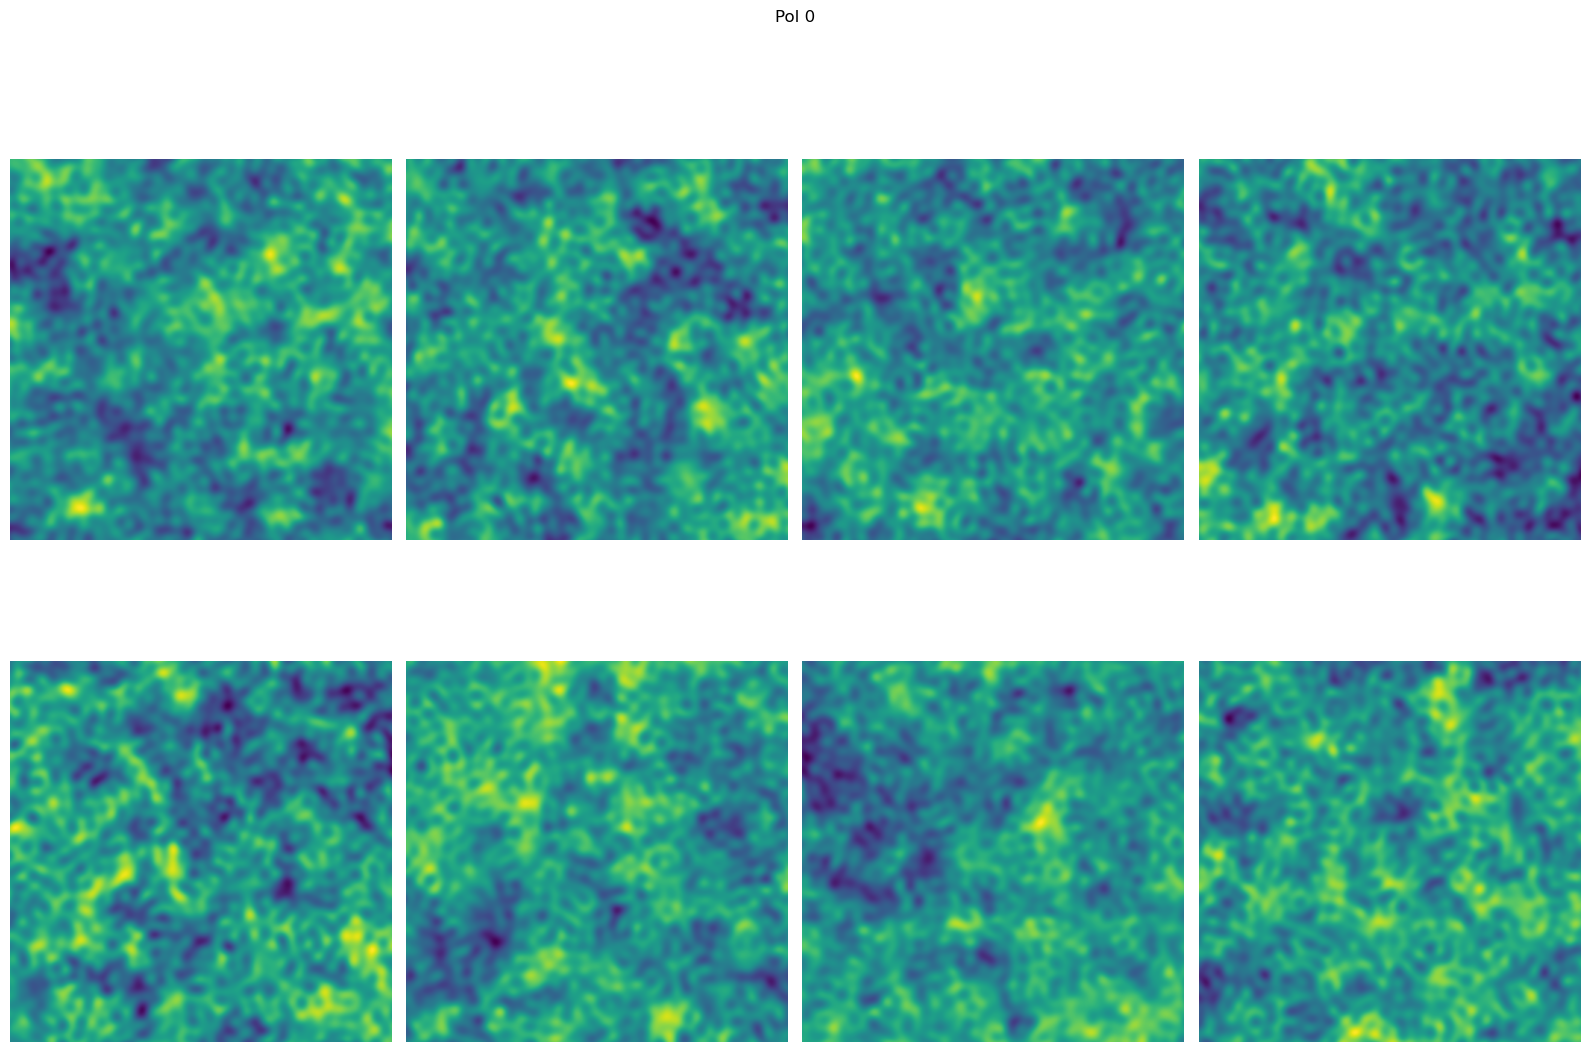

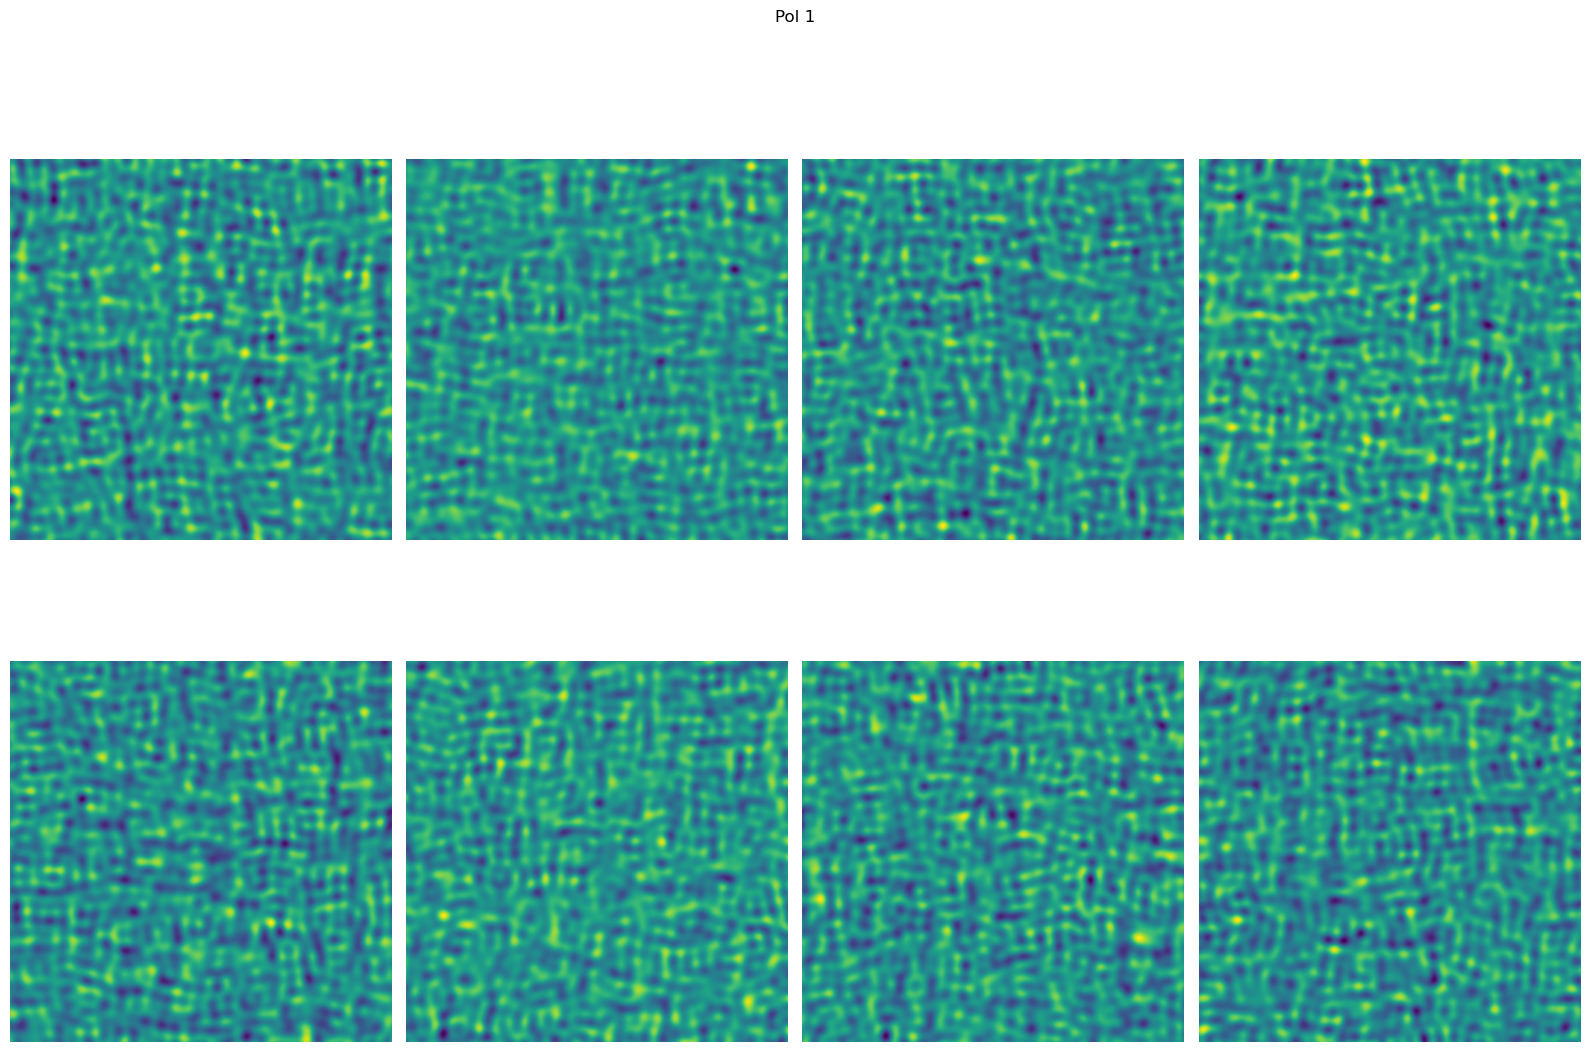

In [19]:
for pol in range(core.npols):
    plot_patches(patches[0, :, pol], title=f"Pol {pol}", show=True)

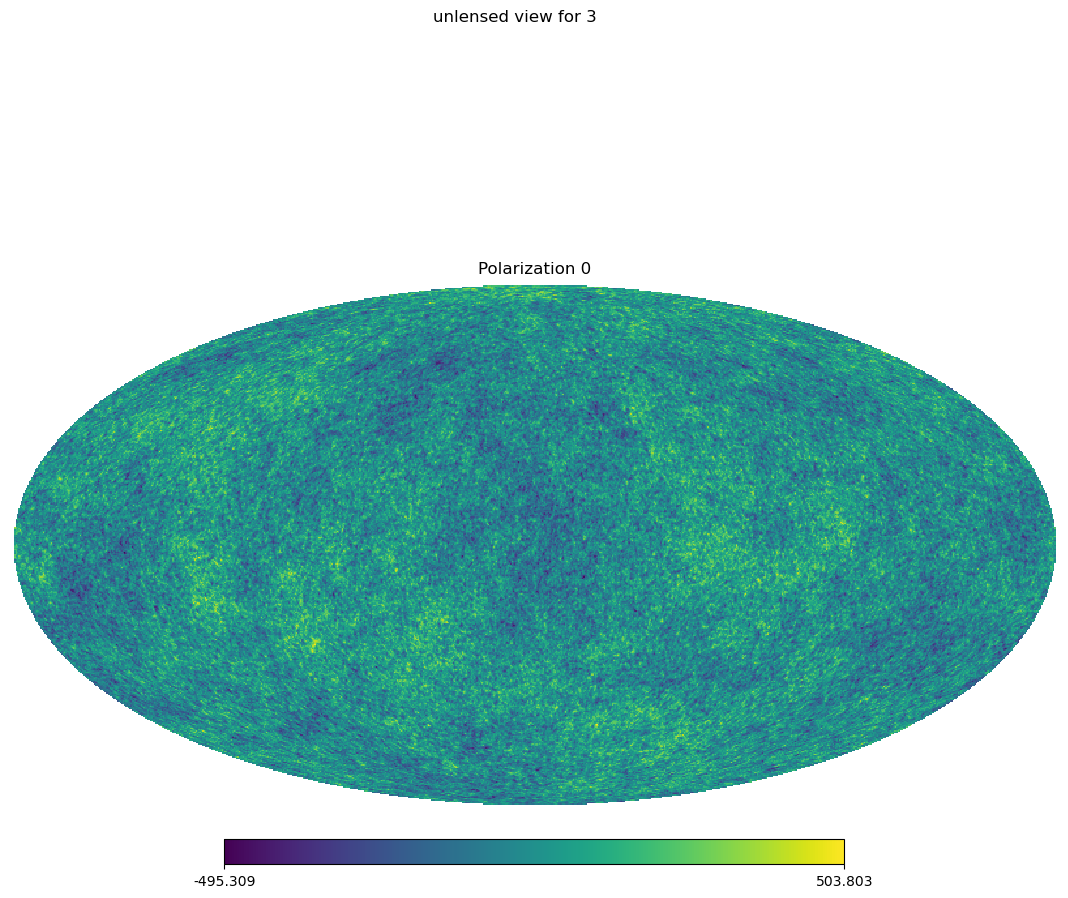

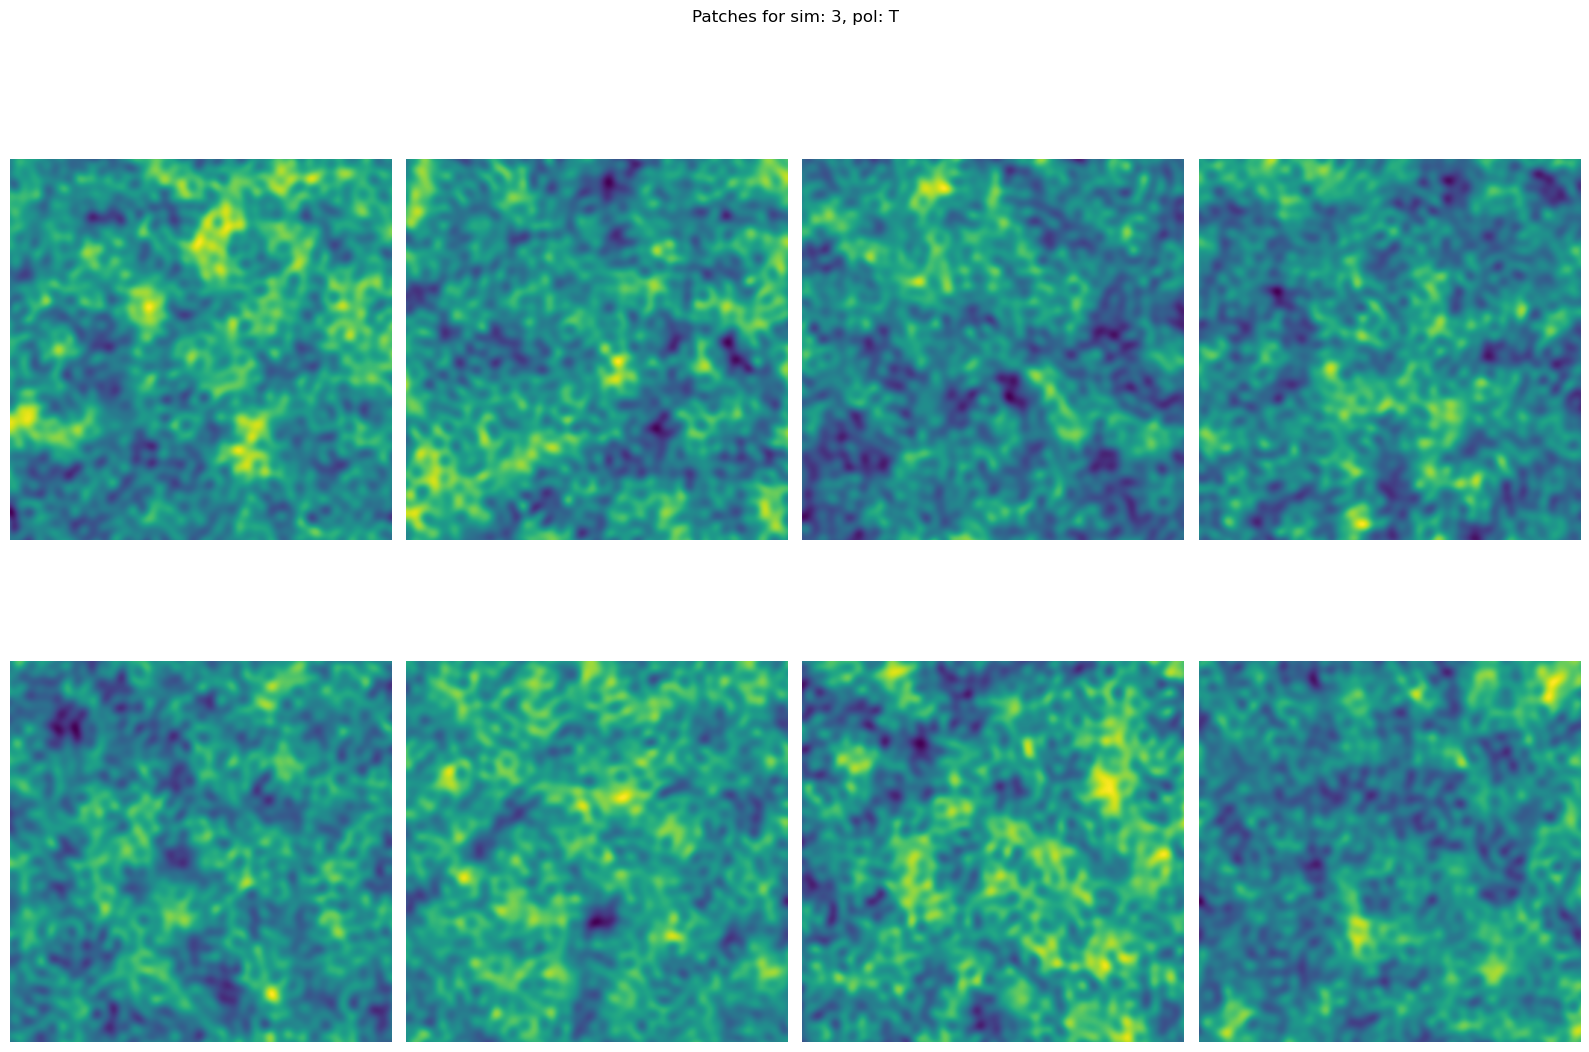

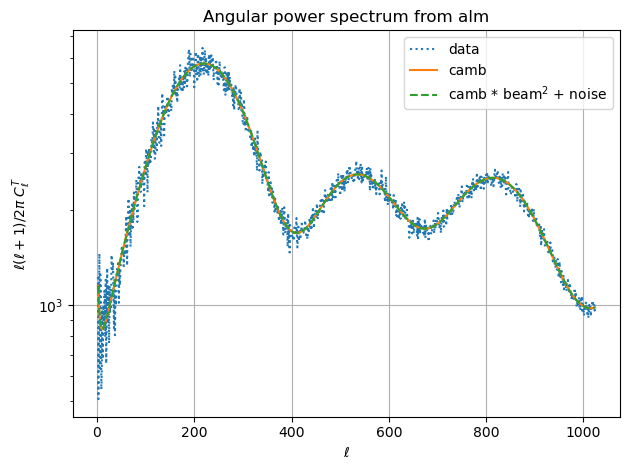

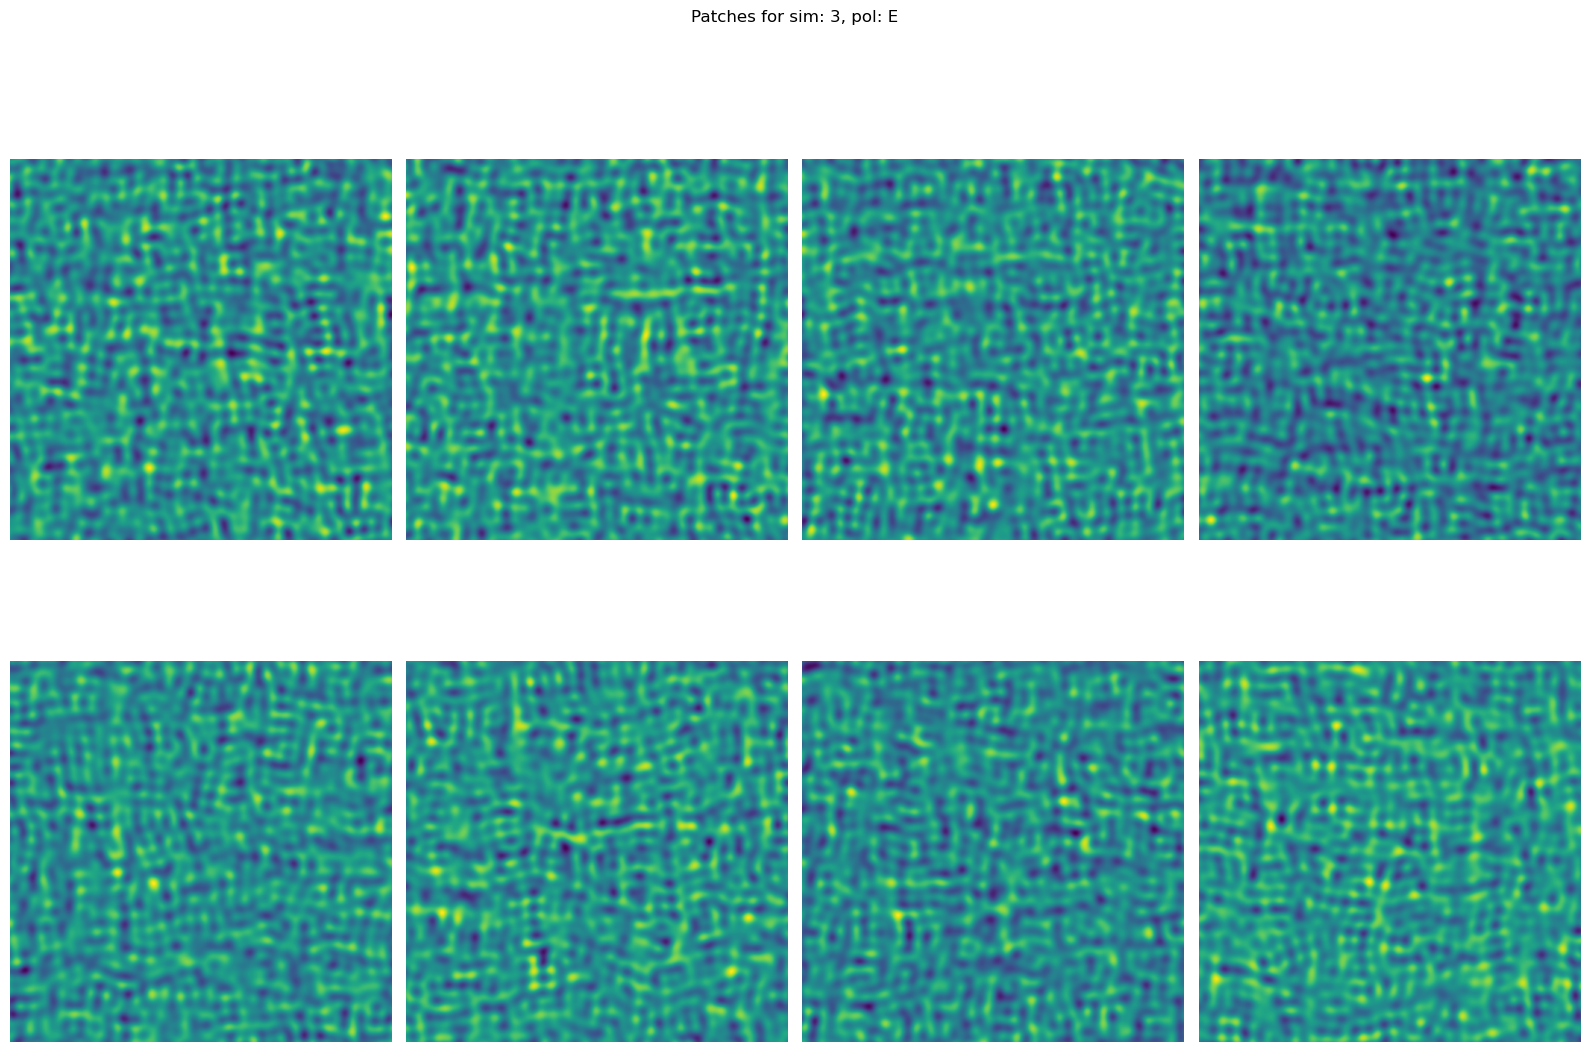

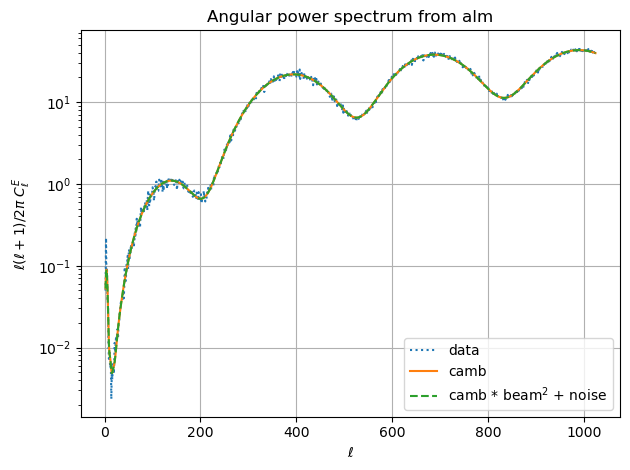

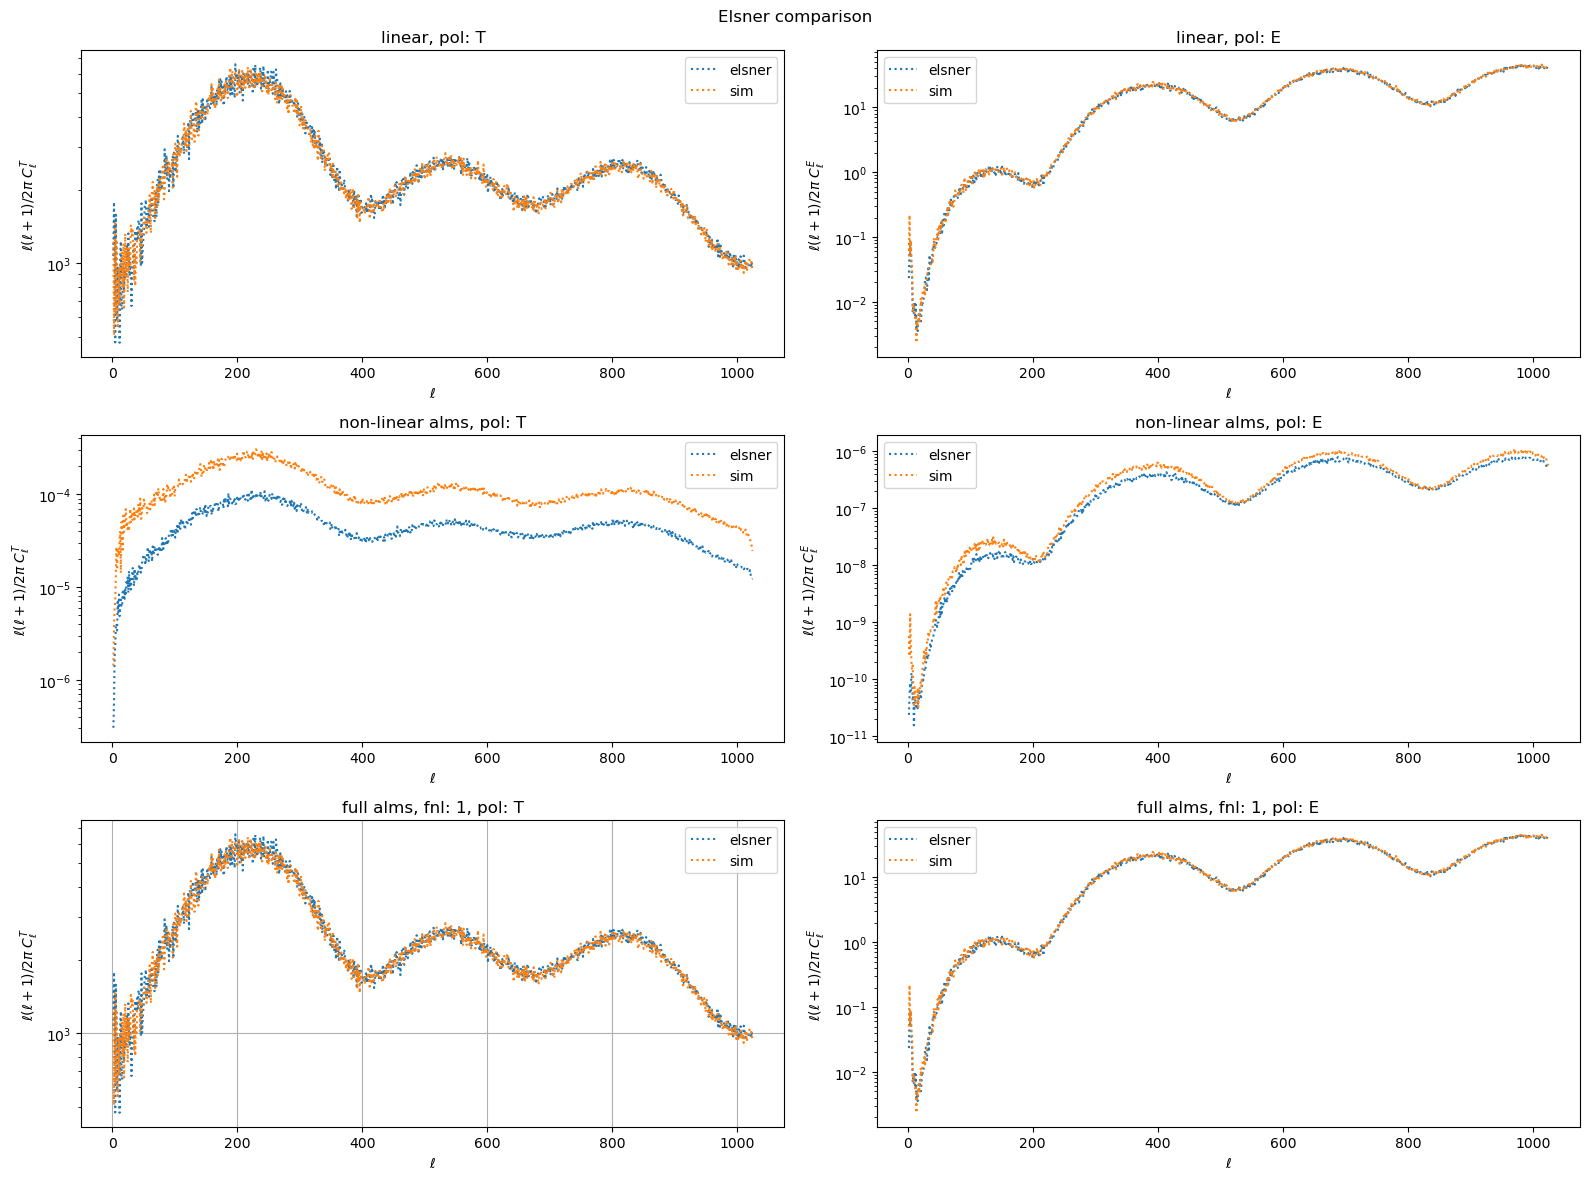

In [20]:
sim = core.rng.integers(core.nsims)
if core.lensing:
    map = lenspyx.alm2lenmap(alms[sim], dlm, geom_info, nthreads=core.n_cpus)
    plot_mollview(map, f"Lensed view for {sim}", show=True)
else:
    map = curvedsky.alm2map_healpix(
        alms[sim, 0], nside=core.nside, copy=True, nthread=core.n_cpus
    )
    plot_mollview(map, f"unlensed view for {sim}", show=True)

for pol in range(core.npols):
    pstr = pol_str(pol)
    plot_patches(
        patches[sim, :, pol], title=f"Patches for sim: {sim}, pol: {pstr}", show=True
    )

    ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
    plot_cl_alm(
        alms[sim, pol],
        # save_file=filebase,
        plot_camb=True,
        ylabel=ylabel,
        camb_cls=c_ells[pol],
        plot_noise=False,
        plot_full_camb=True,
        camb_noise=core.noise_ell[pol],
        camb_beam=core.beam_ell[pol],
        show=True,
    )

plot_elsner_comp(
    alm_l[sim], alm_ng[sim], elsner_idx=core.rng.integers(1, 1001), show=True
)

## Estimator

In [21]:
loc_shape = Shape.prim_local(core.cosmo_params["ns"], core.cosmo_params["pivot_scalar"])
cosmo.add_prim_reduced_bispectrum(loc_shape, core.radii)

ksw = KSW(
    cosmo.red_bispectra,
    lambda a: a,
    core.lmax,
    core.pols,
    core.precision,
)

In [22]:
theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus

# uncomment to remove the mc file to regenerated
# if os.path.exists(core.mc_file):
#     os.remove(core.mc_file)

# if core.force_ksw_step:
# if os.path.exists(core.mc_file):
#     print("Loading KSW state from ", core.mc_file)
#     ksw.start_from_read_state(core.mc_file, None)
# else:
#     run_ksw_step(ksw, core, theta_batch)
# print("Saving KSW state to", core.mc_file)
# ksw.write_state(core.mc_file)
# fisher = ksw.compute_fisher()  # / core.npols
# print(f"Fisher: {fisher}, standard deviation: {np.sqrt(1 / fisher)}")

In [23]:
with np.errstate(divide="ignore", invalid="ignore"):
    ib = np.where(core.beam_ell != 0, 1 / core.beam_ell, 0)
    cl = np.where(c_ells != 0, c_ells, 0)
    icov = np.where(
        cl + ib * core.noise_ell * ib != 0,
        1 / (cl + ib * core.noise_ell * ib),
        0,
    )
    icov = icov[core.pol_idxs()]

fisher = ksw.compute_fisher_isotropic(icov)
print(f"Fisher: {fisher}, fisher error: {1 / np.sqrt(fisher)}")

Fisher: 0.08503615856170654, fisher error: 3.42924255738036


In [24]:
# fisher = ksw.compute_fisher_isotropic(core.icov_tot[core.pol_idxs()])
# print(f"Fisher: {fisher}, standard deviation: {np.sqrt(1 / fisher)}")

In [25]:
def alm_loader(i):
    if core.lensing:
        return alm_lensed[i, : core.npols]
    else:
        return alms[i, : core.npols]

icov = 1 / c_ells
def icov_func(alm):
    ret = np.zeros_like(alm)
    for pol in range(core.npols):
        ret[pol] = hp.almxfl(alm[pol], icov[pol])
    return ret


idxs = range(alms.shape[0])
icov_alms = [icov_func(alm_loader(i)) for i in idxs]
estimates, _, _, _ = ksw.compute_estimate_batch(
    lambda i: icov_alms[i], idxs, theta_batch=theta_batch, fisher=fisher, lin_term=0
)
# estimates, _, _, _ = ksw.compute_estimate_batch(
#     lambda i: alm_loader(i), idxs, theta_batch=theta_batch, fisher=fisher, lin_term=0
# )

/tmp/ipykernel_1314892/395639201.py:7: RuntimeWarning: divide by zero encountered in divide
  icov = 1 / c_ells


fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616
fnl=nan, t_cubic=nan, lin_term=0, fisher=0.08503616


: 

In [26]:
fnls = np.array(fnls).flatten()
print(fnls)
print_errors(fnls, estimates, fisher)
plot_predictions(fnls, estimates, fisher=fisher, show=True)
plot_histogram(fnls, estimates)